Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

Loading & Shuffling Data

In [2]:
df = pd.read_csv("realistic_migraine_data.csv").sample(frac=1, random_state=42)

X = df.drop("Migraine_Score", axis=1)
y = df["Migraine_Score"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

Training the Random Forest Model with Decision Tree Layering 

In [3]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)
rf_model.fit(X_train, y_train)

pred = rf_model.predict(X_test)

Evaluation

In [4]:
print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R²  :", r2_score(y_test, pred))

MAE : 2.240411531980511
RMSE: 2.923534891419091
R²  : 0.9723570536843216


Visualization

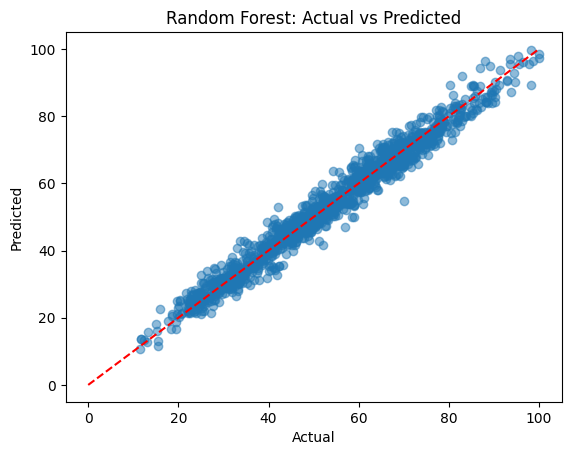

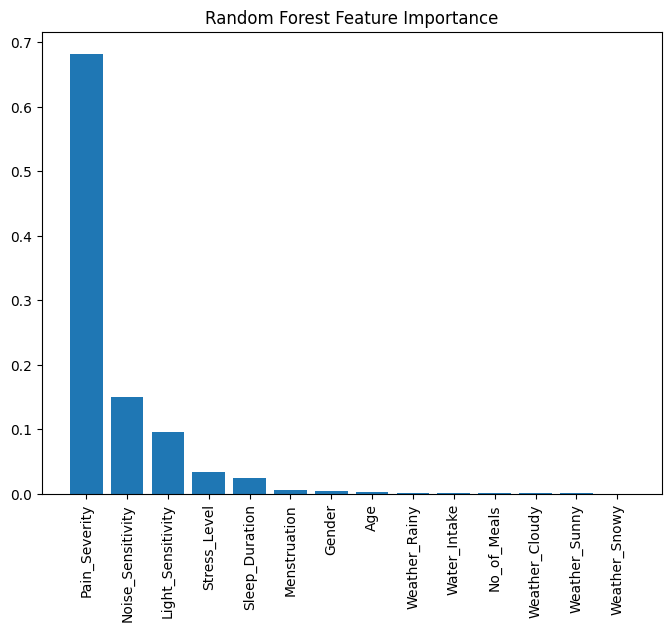

In [5]:
plt.scatter(y_test, pred, alpha=0.5)
plt.plot([0,100], [0,100], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

# Feature importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,6))
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.title("Random Forest Feature Importance")
plt.show()